In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load dataset
df = pd.read_csv("ArmedBirds.csv")

# Display first rows
df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,selftext,link_flair_text,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.360903e+09,265,i.minus.com,18kbd6,When the hunted become the hunters.(x gifs),pencer,284,19,3,http://www.reddit.com/r/ArmedBirds/comments/18...,NaN,NaN,False,NaN,t5_2tgyr,False,NaN,NaN,False,t3_18kbd6,http://i.minus.com/iMh00PnaJExAP.gif,NaN
1,1.346988e+09,247,i.imgur.com,zhki1,I was told to send this over to you guys,DforDrew,260,13,0,http://www.reddit.com/r/ArmedBirds/comments/zh...,NaN,NaN,False,NaN,t5_2tgyr,False,NaN,NaN,False,t3_zhki1,http://i.imgur.com/tbgfM.png,NaN
2,1.350129e+09,244,i.imgur.com,11et6u,So an Osprey was flying near my house today. S...,NaN,260,16,0,http://www.reddit.com/r/ArmedBirds/comments/11...,NaN,NaN,False,NaN,t5_2tgyr,False,NaN,NaN,False,t3_11et6u,http://i.imgur.com/0qJFC.jpg,NaN
3,1.363661e+09,230,i.imgur.com,1akhcl,"This is HAWK-1 reporting in, the target has be...",alexchally,247,17,1,http://www.reddit.com/r/ArmedBirds/comments/1a...,NaN,NaN,False,NaN,t5_2tgyr,False,NaN,NaN,False,t3_1akhcl,http://i.imgur.com/rcqQczX.jpg,NaN
4,1.364407e+09,210,i.imgur.com,1b4fgl,Captain Jack Sparrow!,StartCase,235,25,1,http://www.reddit.com/r/ArmedBirds/comments/1b...,NaN,NaN,False,NaN,t5_2tgyr,False,NaN,NaN,False,t3_1b4fgl,http://i.imgur.com/n8ZYLAC.jpg,NaN


In [3]:
# Dataset info
df.info()

# Summary statistics
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   created_utc             82 non-null     float64
 1   score                   82 non-null     int64  
 2   domain                  82 non-null     str    
 3   id                      82 non-null     str    
 4   title                   82 non-null     str    
 5   author                  81 non-null     str    
 6   ups                     82 non-null     int64  
 7   downs                   82 non-null     int64  
 8   num_comments            82 non-null     int64  
 9   permalink               82 non-null     str    
 10  selftext                1 non-null      str    
 11  link_flair_text         0 non-null      float64
 12  over_18                 82 non-null     bool   
 13  thumbnail               0 non-null      float64
 14  subreddit_id            82 non-null     str    
 15  ed

created_utc                0
score                      0
domain                     0
id                         0
title                      0
author                     1
ups                        0
downs                      0
num_comments               0
permalink                  0
selftext                  81
link_flair_text           82
over_18                    0
thumbnail                 82
subreddit_id               0
edited                     0
link_flair_css_class      82
author_flair_css_class    81
is_self                    0
name                       0
url                        0
distinguished             82
dtype: int64

In [4]:
# Convert categorical columns to dummy variables
df = pd.get_dummies(df, drop_first=True)

df.head()

,created_utc,score,ups,downs,num_comments,link_flair_text,over_18,thumbnail,edited,link_flair_css_class,author_flair_css_class,is_self,distinguished,domain_i.minus.com,domain_images.hellokids.com,domain_imgur.com,domain_kickstarter.com,domain_noworld.net.tf,domain_reddit.com,domain_self.ArmedBirds,domain_thishin.wordpress.com,domain_wizards.com,id_1148j4,id_119von,id_11et6u,id_11lkmr,id_11yjkf,id_12nhjs,id_13f6aw,id_14ku4d,id_15fhpu,id_169fpx,id_16egle,id_16pb0m,id_16qo6n,id_16y187,id_17gm3p,id_17hg41,id_182ceb,id_184d8i,...,url_http://i.imgur.com/orH6LFM.jpg,url_http://i.imgur.com/ravW2XU.png,url_http://i.imgur.com/rcqQczX.jpg,url_http://i.imgur.com/tbgfM.png,url_http://i.imgur.com/uhZP8.jpg,url_http://i.imgur.com/w5oQFrq.png,url_http://i.imgur.com/wAnEGcw.jpg,url_http://i.imgur.com/wCy18.png,url_http://i.imgur.com/wTW6TdT.jpg,url_http://i.imgur.com/xE2nZ6T.jpg,url_http://i.imgur.com/xEeuHQo.jpg,url_http://i.imgur.com/y74qa.jpg,url_http://i.imgur.com/zW9svpi.jpg,url_http://i.minus.com/iMh00PnaJExAP.gif,url_http://images.hellokids.com/_uploads/membres/articles/20091043/bad-birds_p4k.png,url_http://imgur.com/30Mle,url_http://imgur.com/6qH5xOw,url_http://imgur.com/6qPJGn2,url_http://imgur.com/EsmiAH2,url_http://imgur.com/FkMkOdK,url_http://imgur.com/GXLqA,url_http://imgur.com/Ghcf6c0,url_http://imgur.com/P08bX,url_http://imgur.com/SffKMii,url_http://imgur.com/XJAm364,url_http://imgur.com/aiwM2,url_http://imgur.com/dX5Re,url_http://imgur.com/ebOfb,url_http://imgur.com/fT6b4,url_http://imgur.com/gallery/ZuD6w,url_http://imgur.com/k8uYN,url_http://imgur.com/nEFwN,url_http://imgur.com/p87Mg,url_http://imgur.com/ux27Pgq,url_http://noworld.net.tf?q2Db6y,url_http://thishin.wordpress.com/2010/08/21/some-funny-pics/world-domination-penguin/,url_http://www.kickstarter.com/projects/fourhorsemen/gothitropolis-raven-action-figure-by-four-horsemen,url_http://www.reddit.com/r/ArmedBirds/comments/p47wd/subreddit_logo/,url_http://www.reddit.com/r/subredditoftheday/comments/1ew0un/may_23rd_2013_rarmedbirds_caw_caw_muthafucker/,url_http://www.wizards.com/dnd/images/ff_gallery/50132.jpg
0,1.360903e+09,265,284,19,3,NaN,False,NaN,False,NaN,NaN,False,NaN,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,1.346988e+09,247,260,13,0,NaN,False,NaN,False,NaN,NaN,False,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,1.350129e+09,244,260,16,0,NaN,False,NaN,False,NaN,NaN,False,NaN,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,1.363661e+09,230,247,17,1,NaN,False,NaN,False,NaN,NaN,False,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,1.364407e+09,

In [6]:
df.columns.tolist()

['created_utc',
 'score',
 'ups',
 'downs',
 'num_comments',
 'link_flair_text',
 'over_18',
 'thumbnail',
 'edited',
 'link_flair_css_class',
 'author_flair_css_class',
 'is_self',
 'distinguished',
 'domain_i.minus.com',
 'domain_images.hellokids.com',
 'domain_imgur.com',
 'domain_kickstarter.com',
 'domain_noworld.net.tf',
 'domain_reddit.com',
 'domain_self.ArmedBirds',
 'domain_thishin.wordpress.com',
 'domain_wizards.com',
 'id_1148j4',
 'id_119von',
 'id_11et6u',
 'id_11lkmr',
 'id_11yjkf',
 'id_12nhjs',
 'id_13f6aw',
 'id_14ku4d',
 'id_15fhpu',
 'id_169fpx',
 'id_16egle',
 'id_16pb0m',
 'id_16qo6n',
 'id_16y187',
 'id_17gm3p',
 'id_17hg41',
 'id_182ceb',
 'id_184d8i',
 'id_18kbd6',
 'id_18nm17',
 'id_18ojgq',
 'id_18onkl',
 'id_18sa9g',
 'id_19rmit',
 'id_19uem9',
 'id_19wrq8',
 'id_19xfe0',
 'id_1akhcl',
 'id_1b0gjp',
 'id_1b4fgl',
 'id_1b5p4f',
 'id_1b6344',
 'id_1b79t6',
 'id_1bb7vt',
 'id_1be97n',
 'id_1bhl2q',
 'id_1bucf0',
 'id_1cylm2',
 'id_1czwws',
 'id_1d0xy1',
 'id_1

In [8]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [9]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



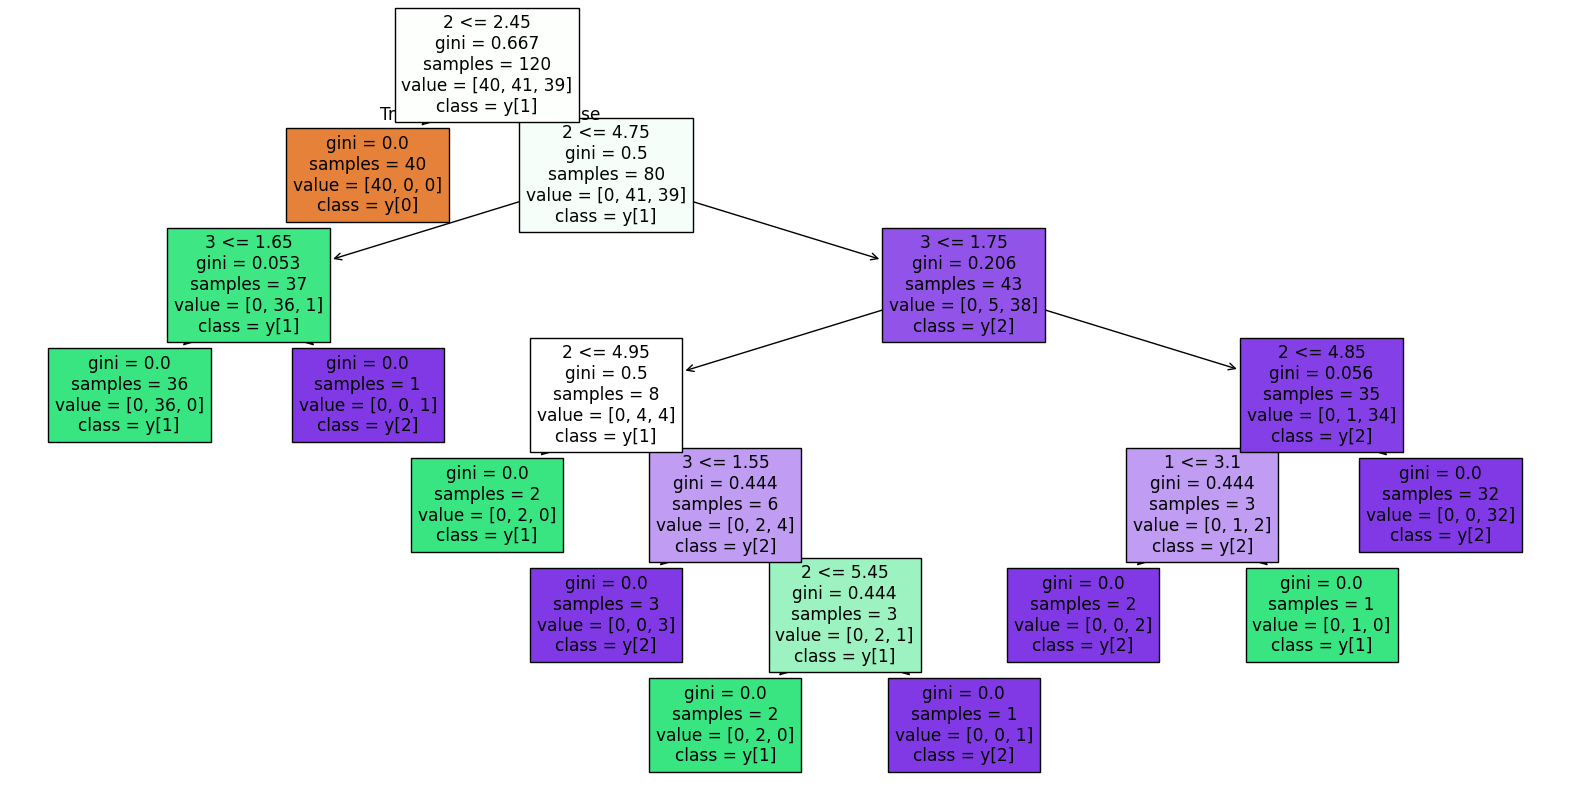

In [11]:
import pandas as pd

X = pd.DataFrame(X)

plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=True,
    filled=True
)

plt.show()

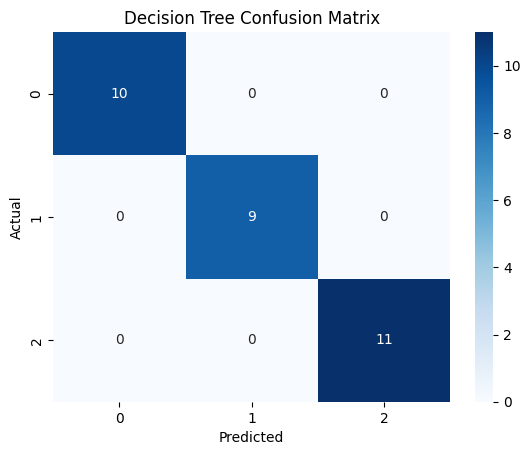

In [12]:
cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

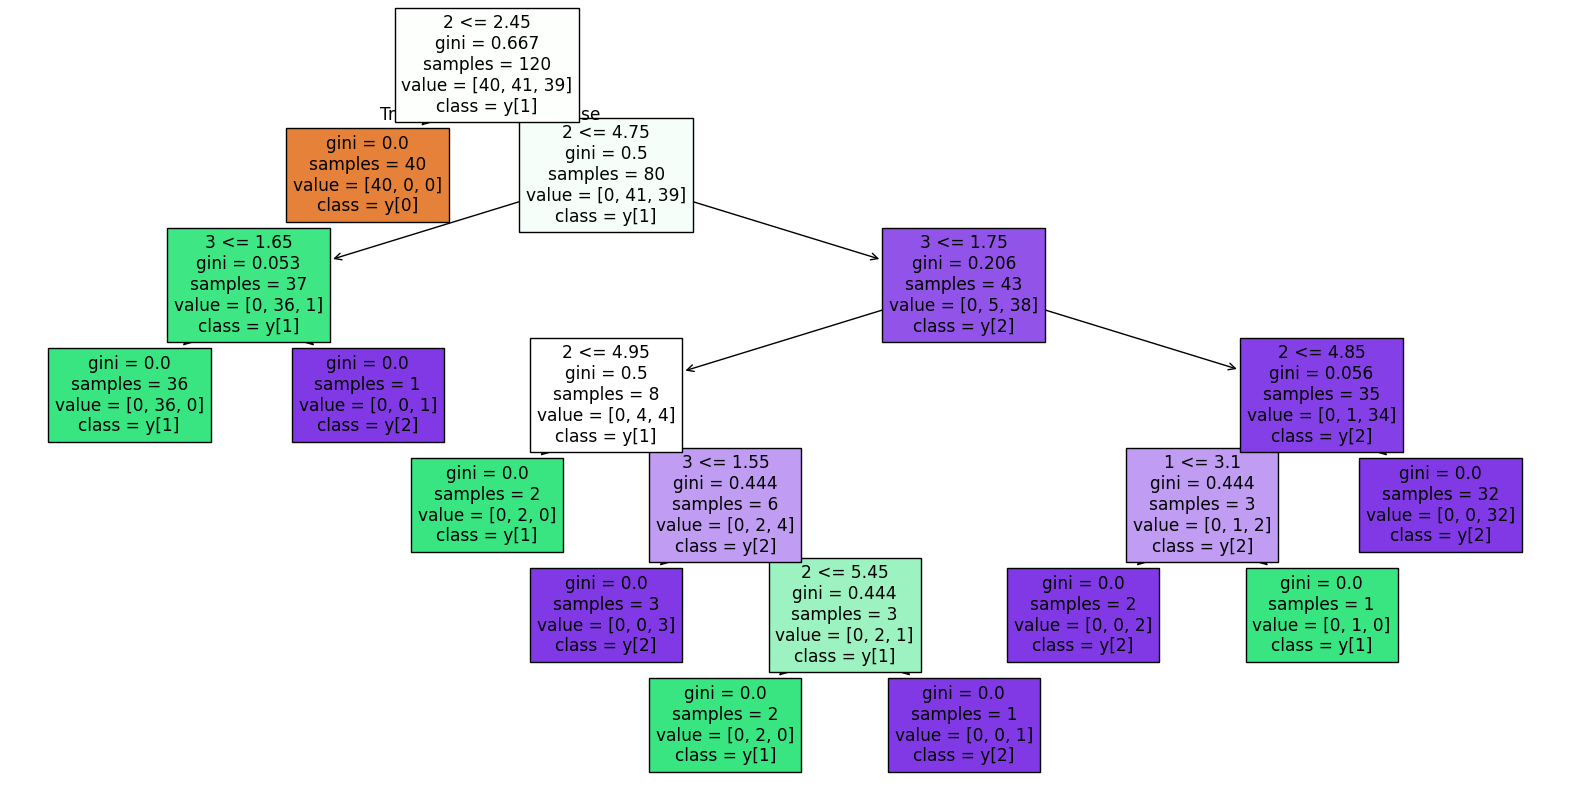

In [13]:
plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=True,
    filled=True
)

plt.show()

In [14]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [15]:
importances = rf_model.feature_importances_

features = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

features

,Feature,Importance
2,2,0.439994
3,3,0.421522
0,0,0.108098
1,1,0.030387


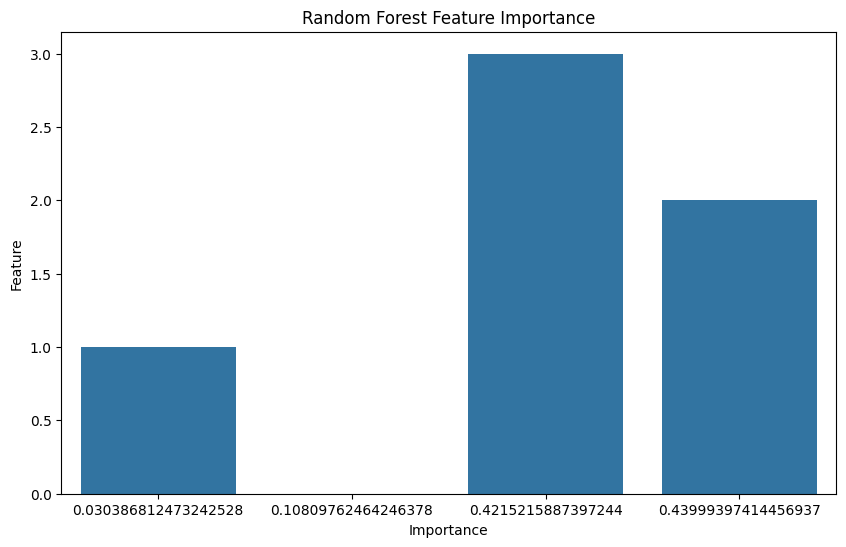

In [16]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=features
)

plt.title("Random Forest Feature Importance")
plt.show()